In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **IMPORTING REQUIRED LIBRARIES**





In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from google.colab import files
import os
import zipfile

from glob import glob
from PIL import Image as pil_image
from matplotlib.pyplot import imshow, imsave
from IPython.display import Image as Image

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.utils import to_categorical
import keras
from keras.models import Model, Sequential
from keras.layers import Dense, Dropout, Flatten, Input, AveragePooling2D, Activation
from keras.layers import Conv2D, MaxPooling2D, BatchNormalization
from keras.layers import Concatenate, GlobalAveragePooling2D, concatenate
from keras.optimizers import Adam, SGD
from keras import regularizers, initializers
from keras.layers import LeakyReLU, ReLU, Softmax
from keras.layers import Reshape, Activation, Conv2D, Input, MaxPooling2D, BatchNormalization, Flatten, Dense, Lambda
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.callbacks import *
from keras.utils import plot_model
from keras.models import load_model

# **IMPORTING KAGGLE API**

In [ ]:
files.upload()
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle
!chmod 600 /root/.kaggle/kaggle.json

import kaggle
print("Imported kaggle API successfully !")

Saving kaggle.json to kaggle.json
Imported kaggle API successfully !


# **DOWNLOADING HAM10000 DATASET FROM KAGGLE**

In [ ]:
print("Downloading dataset : ")
!kaggle datasets download -d kmader/skin-cancer-mnist-ham10000
print("Downloaded Successfully!")

Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
100% 5.20G/5.20G [04:43<00:00, 19.7MB/s]

Downloaded Successfully!


# **EXTRACTING DATASET AND REMOVING UNWANTED FILES**

In [ ]:
zip_ref = zipfile.ZipFile('skin-cancer-mnist-ham10000.zip', 'r')
zip_ref.extractall()
zip_ref.close()
os.unlink('skin-cancer-mnist-ham10000.zip')

In [ ]:
print('Moving Images into single directory')
# CREATING IMAGE DIRECTORY
os.mkdir('images')
# MOVING FILES TO IMAGE FOLDER
import shutil
destination = "/content/images"
source1 = "/content/HAM10000_images_part_1"
source2 = "/content/HAM10000_images_part_2"

dest1 = shutil.move(source1, destination)

dest2 = shutil.move(source2, destination)

Moving Images into single directory


In [ ]:
li = ['hmnist_8_8_RGB.csv',
 'hmnist_8_8_L.csv',
 'hmnist_28_28_RGB.csv',
 'hmnist_28_28_L.csv']
for i in li:
    os.unlink(i)

In [ ]:
# PRINTING FILES IN THE DIRECTORY
os.listdir()

['.config',
 'drive',
 'kaggle.json',
 'ham10000_images_part_2',
 'ham10000_images_part_1',
 'HAM10000_metadata.csv',
 'images',
 'sample_data']

# **DATA ANALYSIS**

In [ ]:
# LOADING THE DATASET CSV IN PANDAS DATAFRAME
main_df = pd.read_csv('HAM10000_metadata.csv')
main_df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


<Axes: xlabel='count', ylabel='dx'>

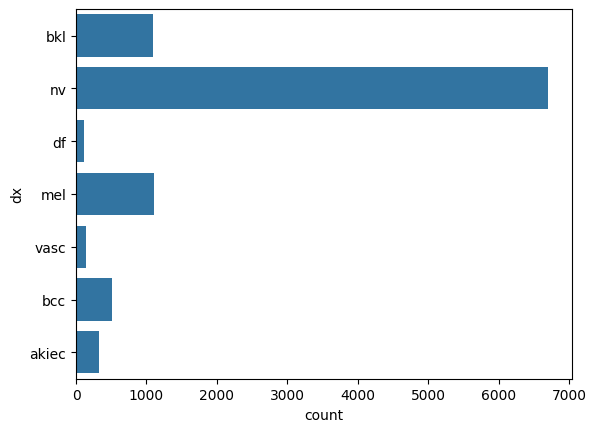

In [ ]:
sns.countplot(main_df['dx'])

In [ ]:
main_df['dx'].value_counts()

,count
dx,
nv,6705
mel,1113
bkl,1099
bcc,514
akiec,327
vasc,142
df,115


(array([   0.,  500., 1000., 1500., 2000., 2500.]),
 [Text(0.0, 0, '0'),
  Text(500.0, 0, '500'),
  Text(1000.0, 0, '1000'),
  Text(1500.0, 0, '1500'),
  Text(2000.0, 0, '2000'),
  Text(2500.0, 0, '2500')])

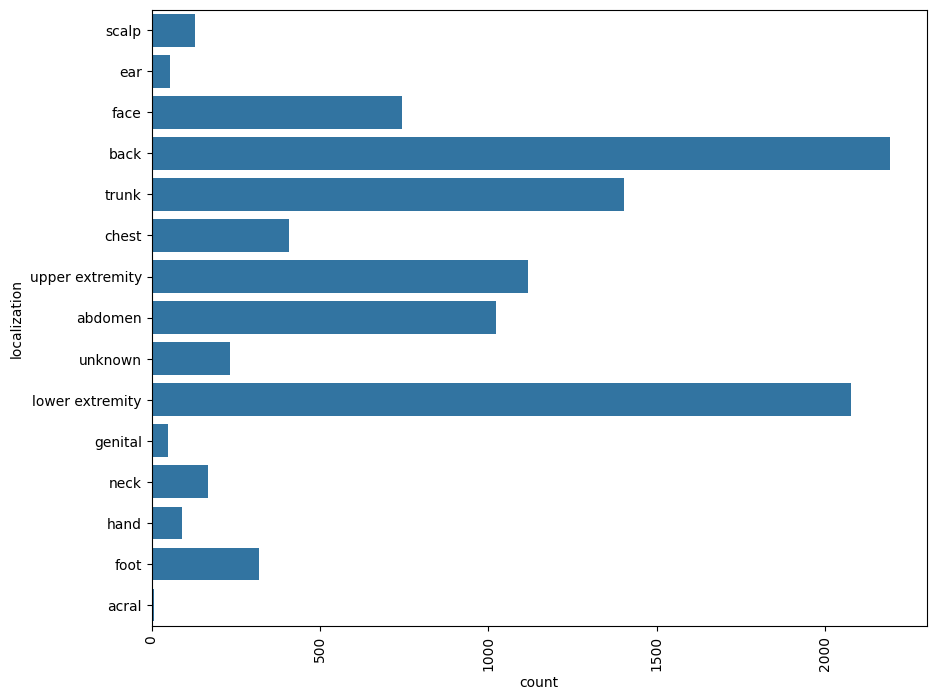

In [ ]:
plt.figure(figsize=(10,8))
sns.countplot(main_df['localization'])
plt.xticks(rotation=90)

<Axes: xlabel='count', ylabel='dx_type'>

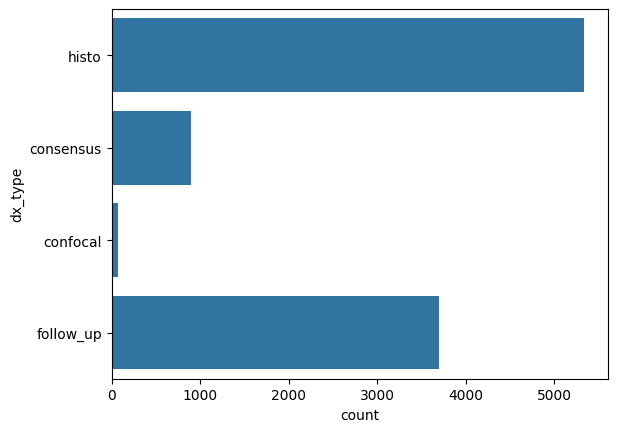

In [ ]:
sns.countplot(main_df['dx_type'])

In [ ]:
main_df['dx_type'].value_counts()

,count
dx_type,
histo,5340
follow_up,3704
consensus,902
confocal,69


In [ ]:
# FINDING THE NUMBER OF MISSING VALUES
main_df.isna().sum().sort_values(ascending=False)

,0
age,57
image_id,0
lesion_id,0
dx,0
dx_type,0
sex,0
localization,0


In [ ]:
print(main_df['age'].mean())
print(main_df['age'].median())
main_df['age'].fillna(main_df['age'].mean(),inplace=True)

51.863828077927295
50.0


/tmp/ipykernel_1922/317226978.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  main_df['age'].fillna(main_df['age'].mean(),inplace=True)


/tmp/ipykernel_1922/330534205.py:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(main_df['age'],shade=True)


<Axes: xlabel='age', ylabel='Density'>

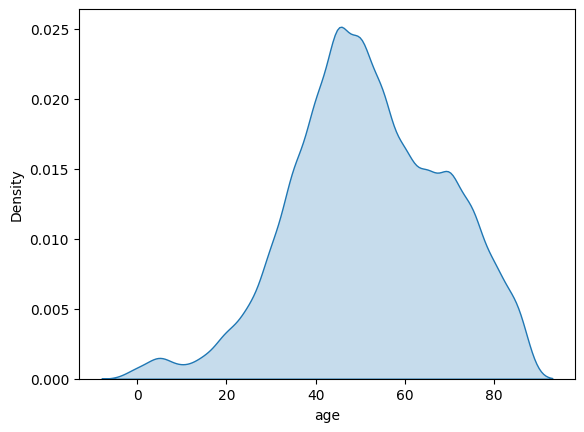

In [ ]:
sns.kdeplot(main_df['age'],shade=True)

In [ ]:
main_df['sex'].value_counts()

,count
sex,
male,5406
female,4552
unknown,57


In [ ]:
# CREATING A DICTIONARY TO FEED IN LABEL VALUES IN OUR DATAFRAME
lesion_type_dict = {
    'nv': 'Melanocytic nevi',
    'mel': 'Melanoma',
    'bkl': 'Benign keratosis-like lesions ',
    'bcc': 'Basal cell carcinoma',
    'akiec': 'Actinic keratoses',
    'vasc': 'Vascular lesions',
    'df': 'Dermatofibroma'
}

lesion_classes_dict = {
    0: 'Melanocytic nevi',
    1: 'Melanoma',
    2: 'Benign keratosis-like lesions ',
    3: 'Basal cell carcinoma',
    4: 'Actinic keratoses',
    5: 'Vascular lesions',
    6: 'Dermatofibroma'
}

main_df['cell_type'] = main_df['dx'].map(lesion_type_dict)

In [ ]:
  main_df['cell_type_idx'] = pd.Categorical(main_df['cell_type']).codes

In [ ]:
# CREATING IMAGE PATH
image_path = {os.path.splitext(os.path.basename(x))[0]: x for x in glob(os.path.join('', '*', '*.jpg'))}

In [ ]:
main_df['path'] = main_df['image_id'].map(image_path.get)
main_df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,cell_type,cell_type_idx,path
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,Benign keratosis-like lesions,2,ham10000_images_part_1/ISIC_0027419.jpg
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,Benign keratosis-like lesions,2,ham10000_images_part_1/ISIC_0025030.jpg
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,Benign keratosis-like lesions,2,ham10000_images_part_1/ISIC_0026769.jpg
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,Benign keratosis-like lesions,2,ham10000_images_part_1/ISIC_0025661.jpg
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,Benign keratosis-like lesions,2,ham10000_images_part_2/ISIC_0031633.jpg


In [ ]:
image_example = np.asarray(pil_image.open(main_df['path'][0]))

In [ ]:
image_example.shape

(450, 600, 3)

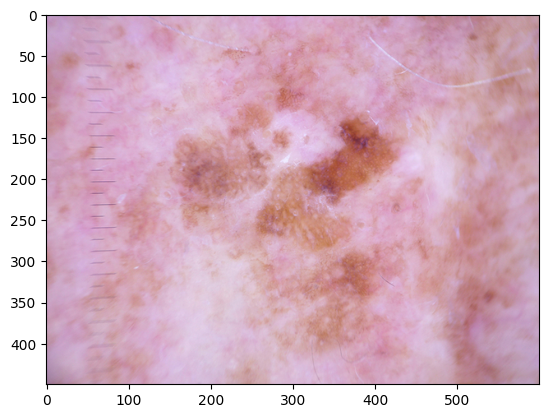

In [ ]:
# PRINTING A SAMPLE IMAGE
plt.imshow(image_example)

In [ ]:
# RESIZING THE IMAGE TO SMALLER SIZE TO MAKE TRAINING EASY
main_df['image'] = main_df['path'].map(lambda x: np.asarray(pil_image.open(x).resize((120,90))))

In [ ]:
main_df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,cell_type,cell_type_idx,path,image
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,Benign keratosis-like lesions,2,ham10000_images_part_1/ISIC_0027419.jpg,"[[[190, 152, 194], [192, 155, 197], [191, 154,..."
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,Benign keratosis-like lesions,2,ham10000_images_part_1/ISIC_0025030.jpg,"[[[24, 13, 22], [24, 14, 23], [24, 14, 26], [2..."
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,Benign keratosis-like lesions,2,ham10000_images_part_1/ISIC_0026769.jpg,"[[[185, 126, 135], [189, 133, 145], [192, 135,..."
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,Benign keratosis-like lesions,2,ham10000_images_part_1/ISIC_0025661.jpg,"[[[24, 11, 17], [25, 11, 20], [31, 16, 27], [4..."
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,Benign keratosis-like lesions,2,ham10000_images_part_2/ISIC_0031633.jpg,"[[[131, 89, 111], [143, 98, 121], [153, 108, 1..."


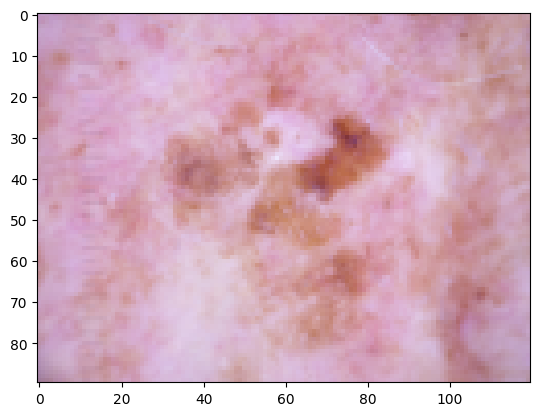

In [ ]:
plt.imshow(main_df['image'][0])

In [ ]:
main_df['image'][0].shape

(90, 120, 3)

# **PRINTING IMAGES OF EACH CLASS**

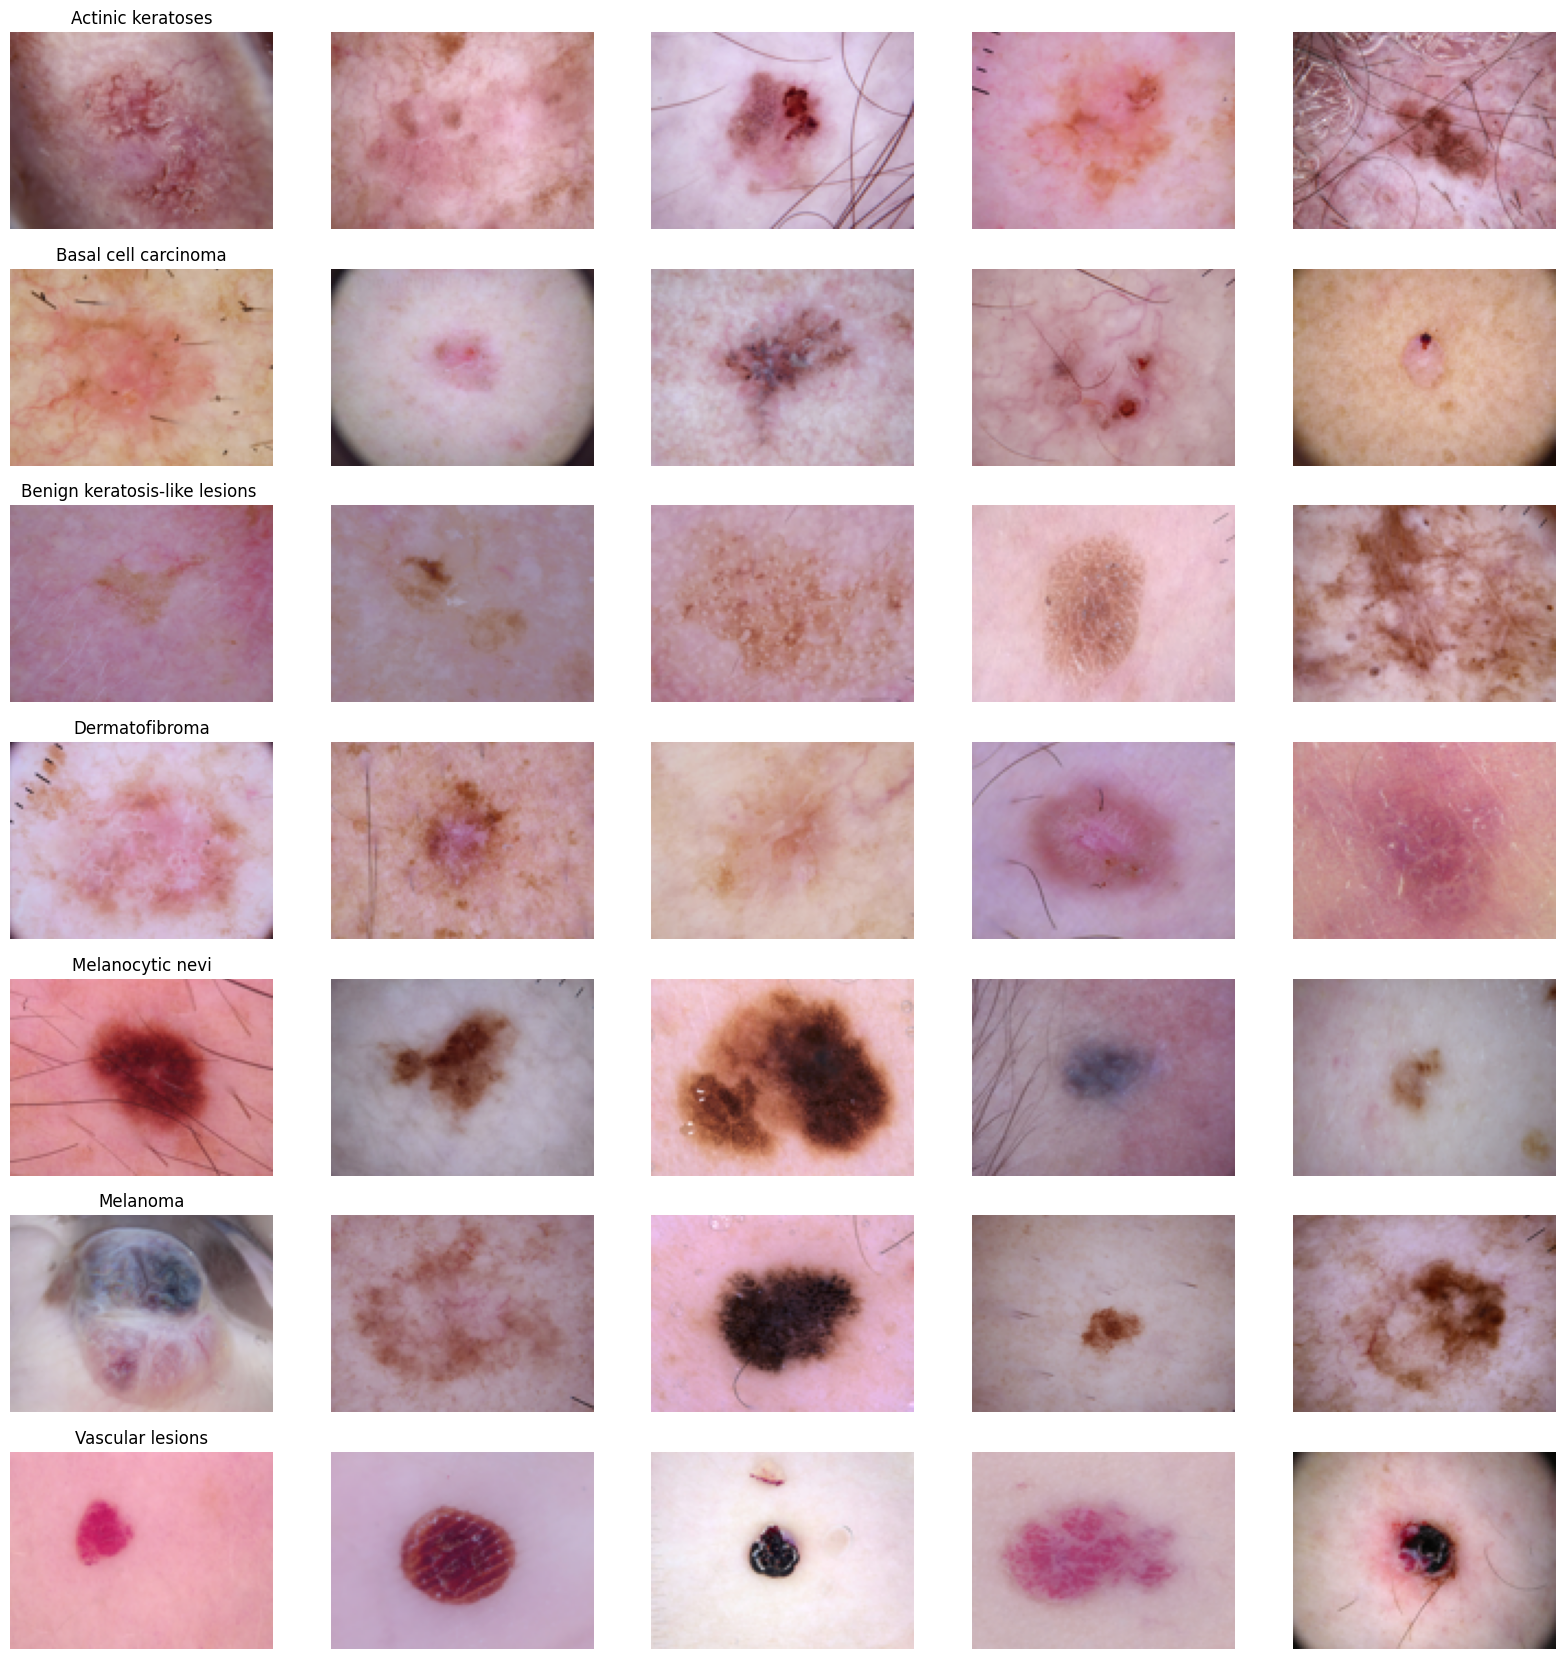

In [ ]:

fig,axes = plt.subplots(7,5,figsize=(20,21))
for nth_axis,(cell_type_name,cell_type_row) in zip(axes,main_df.sort_values(['cell_type']).groupby('cell_type')):
    nth_axis[0].set_title(cell_type_name)
    for column_axis,(_,column_row) in zip(nth_axis,cell_type_row.sample(5).iterrows()):
        column_axis.imshow(column_row['image'])
        column_axis.axis('off')

# **DATA PROCESSING AND MODELING**

In [ ]:
features = main_df.drop(['cell_type_idx'],axis=1)

target = main_df['cell_type_idx']

# SPLITTING THE DATASETS INTO TRAIN AND TEST SET
X_TRAIN, X_TEST, Y_TRAIN, Y_TEST = train_test_split(features,target,test_size=0.01)

In [ ]:
# CREATING IMAGE TRAINING AND TEST SET
x_train = np.asarray(X_TRAIN['image'].tolist())
x_test = np.asarray(X_TEST['image'].tolist())

In [ ]:
print(x_train.shape)
print(x_test.shape)

(9914, 90, 120, 3)
(101, 90, 120, 3)


In [ ]:
train_mean = x_train.mean()
train_std = x_train.std()
test_mean = x_test.mean()
test_std = x_test.std()

In [ ]:
print(train_mean)
print(train_std)
print(test_mean)
print(test_std)

159.78939978257458
46.46185326007817
162.53156857352403
45.601766122218365


# **IMAGE STANDARDIZATION**

In [ ]:
x_train = (x_train-train_mean) / train_std
x_test = (x_test-test_mean) / test_std

In [ ]:
print(Y_TRAIN.shape)
print(Y_TEST.shape)

(9914,)
(101,)


In [ ]:
# CONVERTING NX1 TO NX7 SINCE WE HAVE 7 CLASSES
y_train = to_categorical(Y_TRAIN,num_classes=7)
y_test = to_categorical(Y_TEST,num_classes=7)

In [ ]:
print(y_train.shape)
print(y_test.shape)

(9914, 7)
(101, 7)


In [ ]:
X_train,X_val, Y_train,Y_val = train_test_split(x_train,y_train,test_size=0.15)

In [ ]:
# RESHAPING SO THAT WE CAN FEED THIS INTO OUR NEURAL NETWORK
X_train  = X_train.reshape(X_train.shape[0],90,120,3)
x_test  = x_test.reshape(x_test.shape[0],90,120,3)
X_val  = X_val.reshape(X_val.shape[0],90,120,3)

In [ ]:
print(X_train.shape)
print(x_test.shape)
print(X_val.shape)

(8426, 90, 120, 3)
(101, 90, 120, 3)
(1488, 90, 120, 3)


# **MODEL**

In [ ]:
# COMMAND TO INSTALL KERAS OPTIMIZERS
!pip install -q efficientnet
!git clone https://github.com/bckenstler/CLR.git
!pip install -q keras-radam
!git clone https://github.com/bojone/accum_optimizer_for_keras.git
!pip install -q keras-lr-multiplier

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.7/50.7 kB 4.5 MB/s eta 0:00:00
Cloning into 'CLR'...
remote: Enumerating objects: 252, done.
remote: Counting objects: 100% (8/8), done.
remote: Compressing objects: 100% (7/7), done.
remote: Total 252 (delta 1), reused 4 (delta 0), pack-reused 244 (from 1)
Receiving objects: 100% (252/252), 2.06 MiB | 34.00 MiB/s, done.
Resolving deltas: 100% (87/87), done.
  Preparing metadata (setup.py) ... done
Cloning into 'accum_optimizer_for_keras'...
remote: Enumerating objects: 59, done.
remote: Total 59 (delta 0), reused 0 (delta 0), pack-reused 59 (from 1)
Receiving objects: 100% (59/59), 16.58 KiB | 16.58 MiB/s, done.
Resolving deltas: 100% (20/20), done.
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 301.1/301.1 kB 25.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 312.5/312.5 kB 29.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/4

In [ ]:
# IMPORTING THE EFFICIENTNETB3 MODEL
import tensorflow as tf
import keras
import efficientnet.tfkeras as efn

In [ ]:
# INITIALIZING THE MODEL
model = efn.EfficientNetB3(weights ='noisy-student', include_top=False,
                           input_shape = (90, 120, 3))

43933088/43933088 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
# IMPORTING LIBRARIES
from tensorflow.keras.layers import GlobalAveragePooling2D,Dropout,Dense
from tensorflow.keras.callbacks import ModelCheckpoint,ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
import tensorflow.keras.backend as K
from tensorflow.keras.models import Sequential,Model

In [ ]:
# MAKING CHANGES IN THE OUTPUT LAYER OF EFFICIENTNETB3 MODEL
x = model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)
x = Dense(64, activation="relu")(x)
predictions = Dense(7, activation="softmax")(x)
model = Model(inputs=model.input, outputs=predictions)

In [ ]:
from tensorflow.keras.metrics import Recall

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy', Recall()]
)

In [ ]:
# SET A LEARNING RATE ANNEALER
learning_rate_reduction = ReduceLROnPlateau(monitor='val_loss',
                                            patience=3,
                                            factor=0.5,
                                            min_lr=0.000001)

# **TRAINING THE DATA**

In [ ]:
# WITH DATA AUGMENTATION TO PREVENT OVERFITTING

datagen = ImageDataGenerator(
        rotation_range=10,  # RANDOMLY ROTATE IMAGES IN THE RANGE (0 - 180)
        zoom_range = 0.1 # RANDOMLY ZOOM IMAGES
)


# FIT THE MODEL
epochs = 20
batch_size = 16
model.fit(datagen.flow(X_train,Y_train, batch_size=batch_size),
                              epochs = epochs, validation_data = (X_val,Y_val),
                              verbose = 1, steps_per_epoch=X_train.shape[0] // batch_size
                              , callbacks=[learning_rate_reduction])

Epoch 1/20
526/526 ━━━━━━━━━━━━━━━━━━━━ 308s 283ms/step - accuracy: 0.6992 - loss: 0.8745 - recall: 0.5825 - val_accuracy: 0.7130 - val_loss: 0.8223 - val_recall: 0.6398 - learning_rate: 0.0010
Epoch 2/20
  1/526 ━━━━━━━━━━━━━━━━━━━━ 52s 99ms/step - accuracy: 0.5625 - loss: 0.7567 - recall: 0.5625

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


526/526 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5625 - loss: 0.7567 - recall: 0.5625 - val_accuracy: 0.7144 - val_loss: 0.8016 - val_recall: 0.6391 - learning_rate: 0.0010
Epoch 3/20
526/526 ━━━━━━━━━━━━━━━━━━━━ 41s 79ms/step - accuracy: 0.7415 - loss: 0.7321 - recall: 0.6576 - val_accuracy: 0.7540 - val_loss: 0.7213 - val_recall: 0.7009 - learning_rate: 0.0010
Epoch 4/20
526/526 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5000 - loss: 1.4950 - recall: 0.5000 - val_accuracy: 0.7527 - val_loss: 0.7236 - val_recall: 0.7016 - learning_rate: 0.0010
Epoch 5/20
526/526 ━━━━━━━━━━━━━━━━━━━━ 80s 77ms/step - accuracy: 0.7631 - loss: 0.6653 - recall: 0.6847 - val_accuracy: 0.7708 - val_loss: 0.7318 - val_recall: 0.7211 - learning_rate: 0.0010
Epoch 6/20
526/526 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6875 - loss: 0.9239 - recall: 0.6250 - val_accuracy: 0.7742 - val_loss: 0.7193 - val_recall: 0.7231 - learning_rate: 0.0010
Epoch 7/20
526/526 ━━━━━━━━━━━━━━━━━━━━ 40s 77ms/step - a

# **PLOTTING GRAPH**

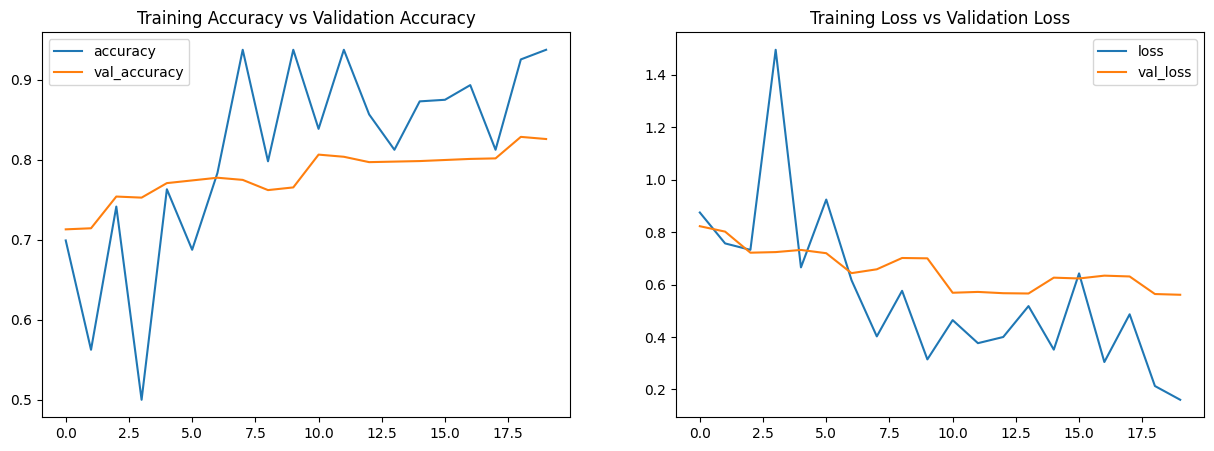

In [ ]:
def plot_(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']

    loss = history.history['loss']
    val_loss = history.history['val_loss']

    f, [ax1, ax2] = plt.subplots(1,2, figsize=(15, 5))
    ax1.plot(range(len(acc)), acc, label="accuracy")
    ax1.plot(range(len(acc)), val_acc, label="val_accuracy")
    ax1.set_title("Training Accuracy vs Validation Accuracy")
    ax1.legend()

    ax2.plot(range(len(loss)), loss, label="loss")
    ax2.plot(range(len(loss)), val_loss, label="val_loss")
    ax2.set_title("Training Loss vs Validation Loss")
    ax2.legend()


plot_(model.history)

In [ ]:
from sklearn.metrics import classification_report

y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

print(classification_report(y_true, y_pred_classes))

4/4 ━━━━━━━━━━━━━━━━━━━━ 36s 7s/step
              precision    recall  f1-score   support

           0       0.50      0.33      0.40         3
           1       1.00      0.50      0.67         6
           2       0.82      0.75      0.78        12
           3       0.00      0.00      0.00         0
           4       0.94      0.95      0.95        66
           5       0.65      0.79      0.71        14

    accuracy                           0.86       101
   macro avg       0.65      0.55      0.58       101
weighted avg       0.88      0.86      0.86       101



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


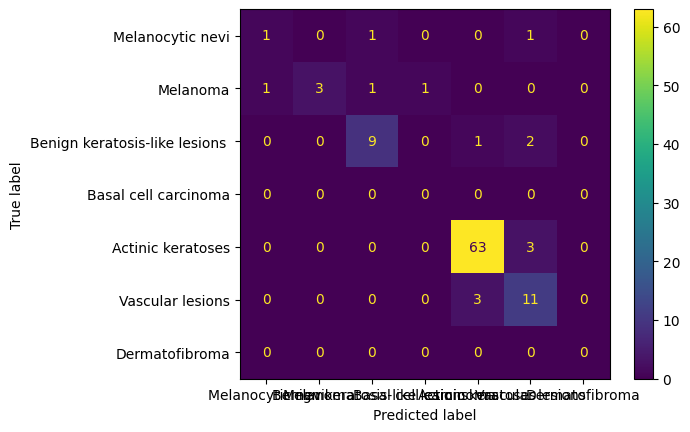

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_true, y_pred_classes, labels=list(lesion_classes_dict.keys()))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=lesion_classes_dict.values())
disp.plot()
plt.show()

In [ ]:
# PRINTING THE ACCURACY OF THE MODEL
print("MAXIMUM ACCURACY : ",
      round(max(model.history.history["val_accuracy"])*100,4))

MAXIMUM ACCURACY :  82.8629


# **SAVING THE MODEL**

In [ ]:
model.save("/content/drive/MyDrive/skin_cancer_efficientnetb3.h5")

# **PREDICTION OF IMAGE**

Original Shape of image is: (225, 225, 3)


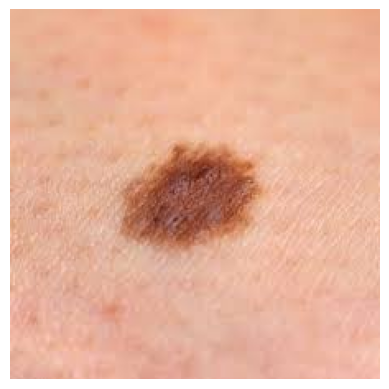

In [ ]:
import base64
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image as pil_image
from io import BytesIO

# Your base64 string here
data_url = "data:image/jpeg;base64,/9j/4AAQSkZJRgABAQAAAQABAAD/2wCEAAkGBxMSEhUTEhIVFRUVFRUVFxUVFRUVFRUVFRcWFxUVFRUYHSggGBolGxcVITEhJSkrLi4uFx8zODMtNygtLisBCgoKDg0OGhAQGi0lHyUtLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLf/AABEIAOEA4QMBIgACEQEDEQH/xAAaAAADAQEBAQAAAAAAAAAAAAABAgMABAUG/8QAMBAAAgIABAQEBgMBAAMAAAAAAAECEQMhMUESUWFxBJGh8AUTgbHB0SLh8TJCUmL/xAAZAQEBAQEBAQAAAAAAAAAAAAABAAIDBQT/xAAeEQEBAQACAwEBAQAAAAAAAAAAARECIRIxQQNRYf/aAAwDAQACEQMRAD8A+4bMg0Y8x7A0ahJSF4yMijQriGLHoCmoDUFoRoj7EVsMQyiBTWIHiFcDcIa3kWix0TghrLaxYpRuEnxFImpWLAoDHaEoRhJAiNKJkiRkYWxgRbMGjBhKxGWoVosOotC0UaJssa1jAMCdDRNlLAzblKFB4QcQk8Ymu6qguRKM7GTI4eLC2KxGyMhwoSLKJhqbhFcB7FcguGadQA4hjI1jACQ6Zoo1EKaxJMYSSEYFhBGBmi1MkFxAmCUwDADF2NwF7OptiSkVaEcSJEwDtA4SIUYNGAhAdyETCzpjjvYXYjw8ygKLGpW4QxDZGeKwuRqdrsDiGOhuIFoxQ1E+IpFWCGw8IEjcRIzQIxBxDwdlqNFE2VQsokonxGDGA1FFQ4jcRpITgEGC4GjAMiZ0EqDZOYIgcNJCUUsxYU6G4TSYvGRwaCT+YYjiSiwo6GLwm3HXK27OiCBQ0XRnDaLQOFBaAKlNIlQ5h6alJh4WeZ0UaBkzOLdKxoRCph4hkOhwDJUCwOQI9gsVDwiSFIm2O5AZBOUwxmUnhiTjQ4ujcQGxDJAsaQtDKLHZDUWzRK8IFEMa1miMoFWAjEOAxWglh8kpzDHEH+WHh+xrK53EZCQbex0xSGosGkWhpDuJOUQqgLMaWG8jYcVsU4infs2gkCboN5jNIsOufPzKxiNNZWaDsMw+QuIsoseU0GM0xGkwo08ystQzkhUxz+DdLRowY0ZD3l0DDaBOTKSZNsRBhANk+IyfMpVYpYJMXiFlLIhIZmRLjGjPMjjNi2WkheEsPknZh/lsxYvKFlicthIysCTzGnk+xSo1gnLISEd2DEhZWjD8eVCrEvQywqQ8MNDINjQlu+XmZz37Glh++hKeG3p76lVMU47KJoTDwqXXf9Dx9EZyq2Diyy6Im3WoniMWMc5eRxeI8dGKu1tSC3K1xlrk+M/FpYbSSy35K9F3N4H4k5Lidpc9DwPiviXOab0WaW7r+znl8Ucctt3ySS0Rz7vbv4zMfXP4lxO0/wCK8sh18WTVLkfB4/xlySik0uW73t0VwPin8f45OtV7yHKvCPuPC/EbbTZ6uFjJpZ5HwPgvHRu3quu/5Pc8N8aSWfl+CnPxvY5fnvp9NHEQsczyvCfEVi6bZVyo9LBVb/U6Tlvpx5cfFd4aWYij5jxlkLx08jTG0ko+YriNKVsVPcGk5RoCVFJA4NxWqLmBTBKPMjO32GiR0cbMc/AzB5NZDRnl3yApUxcJ5Xt1yY0IvXnv6DGfScsVK7+v6HT3JvCV87r7rYo1oubd/egNPpvm7/0DdNWTnv5f4Bxt9PeSK0YvoGUqWeqrL39SXC+earstK9QLJ289fOv9EKcXPLvsnuc2P4pRytHP43xPCs7utN72vpoeRKXEnKbap3qk3eiRm1rjw12eMxlJW3lrXRaL09D534r4pt2pdFWt5Ukh/F+Kiru62S3fLr/Z4eNiuemSyS/S8mcpNr6JMRnjyk/1vsTxsaW9aq+HOrTy7nT4TCjbpq1m29E7bSy1/wCWdGLhL+D4Vkm3lV1Glrtn6H0+Ekc7ytrxcKM8SWVxjai5ZrzfL9HqYuEowlWWSrdztZS++T5DYEHSjonkuyvRXkuvURPOlbpVG9orfuHw/XWsNL/y1j1yOzwni42lJ0lvWZ5KlS3cnze/VHV4Hw9yTlvo3ldetUjly4a6TlkfY/BcfDeWGsqzyzPoYS5++h8d4HG4Z5KV5W228lokryyPqPC49pdc32DhZOnL9Jb27ZS025L8iTXr7sTiebenukgRfFmdfblmH4M69/4aSypdv8NGV6een+ZAc8qS7v8ACDEnPDel++puLQMs8gv02/ZZC1+oJPyDLSt9/wAIyRWhvm9DFPmr/wBTFsWOVddvfmaWLt0t/r7CSqqy1XmJjf8AOXJd3Xv0HVgzmvr6FYTvTv5aHMsCnm+uT16HTHd5LbztB2biyX4zvcWCSv6/c0pX2z7+/wBCcbye7WS79PoNZF5d8vbJTeVvPZd9bFw07zeWr6u9PML3bW33ukE7VmPO+JYeWerffLe+h85j4kpSUdc3+HfvkfSfFsThTcnTeX0fL6WfL+MxVolu89G+/JGOU7dvzvTk8W7aSd0mlVZ86a17nFhUtXldRrWreaX76FPGRyrkr5Ws9+VI43wzlxapKlXT9s3xhtd83lapcVZ71ea7AlNurV8OzzSrLzeddzYa4abpSl/zHnWlLkLhytyr/rJytvJ9llZuyiWH+Vk23npnk86bpL7gln0VVovTfQ5XiW7ttJqucn+D08HDpLTiq+i2CTVbjm4HaVdJN7LNyfc7cNOlGDdvZXxcOt31peRwzTvhirztc3kt+XM9n4XhpNXrbfR3kvJfc48uWOsj2vg/w+tVrs0m1aS1+h9FgYNVRwfD0mstdX9T0uOlS107LkPHjPbhz5XTPDvt+efUCjfRL3mKnl3XpuByvJbnRhmuWn3/AKA1W39cvqMny/xGvpm/RFUStvN+9h1HSvp1GrbW83+vU0t177Lp+gWhe2+l/c0o5UgrJLTp+zJ7L3/Qgbjzfv6hEp8vQwaXCk0s+br8j+/fmNLOnkv5PPn/AELgyWbeb1XcJ0aVzpd/2aWNX3eWr1oaSvvn5vcPy8uxpbAw3lVe8yi9X6L2iaerf+3oZy5blGatDBul9PxYuLG9M1mGU6q7zXoDavNmme3g/GlxUnrV/rt/Z4fyLdy1bvpX6Pq/F+GUk8s/eR53ifhrrLf+NbpdDnZd1248pmPlviMlJ0qrd86WlcjjwPC/LjF1vot8skz6XF+DqKVLXbfh6/U5p+Acpe6VaJF5WN9V5eO3rwp4jfDe8Y8oo5HhJOo3/wDXPXd8z2vFeCbWWul8o8lXUlg/D6emdOq582XLntPHjjjwPCSlbUdMstM3dno4fhLjmqd5rdPTloetgeFcUlVrLRUv9O/B+Hr+TfcLb8Wz6+fwvBxUnk2/TsexgfDtFX8mq05nqw8Ckkks+e7s6/DeFzXPNmJwtHL9Zifg/DuK10Wb5vkdnDl9kOktF7oMnu/odpMjhttcsn7X2Hqln/0/TmWUFtlzfYR5/XTogxrR4kvpWXNhlPJvd+2/WhZpfT7hlDLPTfr0HsUkZZe/eozyz16AhHLkvzshm9/JfXJBiTnd29ftloNhQeWdb9lWhpLz96jSq68/McWky5ryAawB2XFK2/oq6L9loRzvyXmV4ay5fjT1Exl05UunMsW6Nr3uzYmm9KrE4lfJc+g93SrK/PMRidb+nRLUmoXb75I6cXDVtZe9hVzKxaGHp70NjLJpPlY8FSvfSjSSy7j8F9p4cK/6z5dO4/y6rnqUy3NW/MmL25cbCVO9zlfg+udeSPRasVx1S31ZrNMuPJXhVy79Sy8CoyTWbZ6HyvfIbg836GfGNedSjDOqsLgrpfUrBV3HjAs1Spwd/vkWv30EUS0dKBApbef6A5P3zHlWokpZV6kYVvOlvqPOS29oR5d/siUMPrkteoeml8OSeun2Gu+wsY7v3yFcby5lrLSlv5BT099gcAqi7tkulrruK450vdZgS9/kMt61oQPl6GH4en2MaHTmm8l2vvmwYyy7o2HHg65E5NtdDMbwk8JPPbL0K6Z+QE797gavfIYKWc6T5mw1kn7sniRbtvfYfBpfTYMKjGTa6kuK/wAlHK8+gjCwf1fIZz59/wCiMZchsRWBw8sS+5k/7FwkkPN5GozYXj32G+Zk3X16GSvIzw9ryJdNCZWE868yWH2HqswXSs5cjOOf3Jxe7HjIsRcW3p2KfhAixeKgwi1sI9uQU613MiaMGU6XVi3b6E7bYLFuLRfVjPLMjBPcf5hpmwy395i1Wf1YF3JyxPKwWKfPZiXEYvJeI4ryvnl2RBz8h57+n0OfxEmqSzr7sbXSR1Qf8QPXpkHDlcfIdp10GVip8GYJx2eo8Yq78gS6hoQ49tjmxPFUqOuWGqOWeB0DlP468c+q+GxumpeO/Qjgc6KUU9Dkd8zPTqKG6FhTDewzRB5FI4tlKzYpHUOWrYANWhAoUX6jqgJXOqCneZuEomWHS1mK4lJ5GKxSpwVXmUixJSDhyCNUzz1EUCilQ0WtfI0NTaWgldBmOlvyyFEzMNZgyAk477iPD99SspK65DyzQNalhYb0BJumiltfyJwt6huJsMKnrYYxay5ksSL0LTjKViz2DhxpCtDL0M7CCqxlJCTWQkpVsDWOiKDwbk4T5lFiZjHOxnEVKjOVDqeQiymUzUIhJTaIYabBGROUwNlrUjo4sh4TIJmuxWLuQVKyb5DQA40kCDGkGCD6S8Nj3l2GSA1lQhPDlq/IMZDQwx4YdB2bYTi6GLZ8jDrLhhC9SqdE4P8AwRYtsMLqj6FIwtHI8QMvE0XpZV2ZkozzS5j+IyL/AEtiUhVRPEk8gKTZWnGlEX5ZSSEnlmQSxo1oCEgcY6fQjhmlWYssTZGeZGKzKrHbgyFmrYMMcWPpVhi8JZgsqk0wSeY7iSjDPMjFYsdoWDKJkihsZSsdRQYWhMCkaCA8McS0Negydsjew0XyIYtx9DE6ZgyjHnS2JPcxjSh5e/QE9jGMcm+K0NUXxtDGKJN7BwwmGoJkcXRmMUTkR0R0MYY1RgJAxhZXhqPLUxgZ+gKYw1HZLEMYFDYegwTFSECy0MYIa0PyOYwz0zfaaHwdzGJr4qYxjTL/2Q=="

# Remove the prefix
base64_data = data_url.split(",")[1]

# Decode image
image_bytes = base64.b64decode(base64_data)

# Open image
image = pil_image.open(BytesIO(image_bytes))

# Convert to numpy array
test_image = np.asarray(image)

print("Original Shape of image is:", test_image.shape)

plt.imshow(test_image)
plt.axis("off")
plt.show()

In [ ]:
# RESIZING THE IMAGE
# Use the 'image' variable (PIL Image object) from the previous cell
resized_pil_image = image.resize((120,90))
# Convert the resized PIL Image to a numpy array
resized_image_array = np.asarray(resized_pil_image)
# Reshape the array as required for the model input
test_image = resized_image_array.reshape(1,90,120,3)

In [ ]:
prediction_class = model.predict(test_image)
prediction_class = np.argmax(prediction_class,axis=1)


1/1 ━━━━━━━━━━━━━━━━━━━━ 23s 23s/step


In [ ]:
prediction_class

array([6])

In [ ]:
# PREDICTING THE IMAGE
lesion_classes_dict[prediction_class[0]]

'Dermatofibroma'